
K_R1s(r) =
+174.7406 * exp(-17.6670 r)
-410.9097 * r * exp(-24.5295 r)
+0.1194 * r * exp(-7.2525 r)
-1639.9959 * r^2 * exp(-21.3493 r)
+0.0070 * r^2 * exp(-3.6185 r)
-0.0012 * r^2 * exp(-2.6126 r)

K_R2s(r) =
-50.7247 * exp(-17.6670 r)
-68.4907 * r * exp(-24.5295 r)
+188.1923 * r * exp(-7.2525 r)
-628.2901 * r^2 * exp(-21.3493 r)
-0.0290 * r^2 * exp(-3.6185 r)
+0.0178 * r^2 * exp(-2.6126 r)

K_R3s(r) =
-17.4957 * exp(-17.6670 r)
-34.9886 * r * exp(-24.5295 r)
+76.5818 * r * exp(-7.2525 r)
-316.8749 * r^2 * exp(-21.3493 r)
-24.3298 * r^2 * exp(-3.6185 r)
-5.3691 * r^2 * exp(-2.6126 r)

K_R2p(r) =
+7.2527 * r * exp(-28.8909 r)
+198.1262 * r * exp(-11.9319 r)
+43.0834 * r * exp(-6.0967 r)
+0.0414 * r * exp(-2.5605 r)
+325.5405 * r^2 * exp(-9.4272 r)
-0.0055 * r^2 * exp(-2.1782 r)
+0.0001 * r^2 * exp(-1.3295 r)

K_R3p(r) =
-1.7717 * r * exp(-28.8909 r)
-43.6437 * r * exp(-11.9319 r)
-45.9502 * r * exp(-6.0967 r)
+10.6248 * r * exp(-2.5605 r)
-16.7563 * r^2 * exp(-9.4272 r)
+2.0070 * r^2 *

/tmp/ipykernel_12455/3876469695.py:136: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  val = np.sqrt(2/np.pi) * np.trapz(integrand, r_grid)


           Q  J_1s_one_electron  J_2s_one_electron  J_3s_one_electron  \
0       0.00           0.043993       1.617177e-01       4.252757e-01   
1       0.05           0.043992       1.616728e-01       4.240200e-01   
2       0.10           0.043989       1.615379e-01       4.202780e-01   
3       0.15           0.043985       1.613133e-01       4.141234e-01   
4       0.20           0.043978       1.609995e-01       4.056760e-01   
...      ...                ...                ...                ...   
1996   99.80           0.000002       1.356694e-07       1.624039e-08   
1997   99.85           0.000002       1.350692e-07       1.616849e-08   
1998   99.90           0.000002       1.344711e-07       1.609684e-08   
1999   99.95           0.000002       1.338749e-07       1.602543e-08   
2000  100.00           0.000001       1.332808e-07       1.595426e-08   

      J_2p_one_electron  J_3p_one_electron  J_4s_one_electron   J_1s(2)  \
0          9.018632e-02       3.304013e-01      

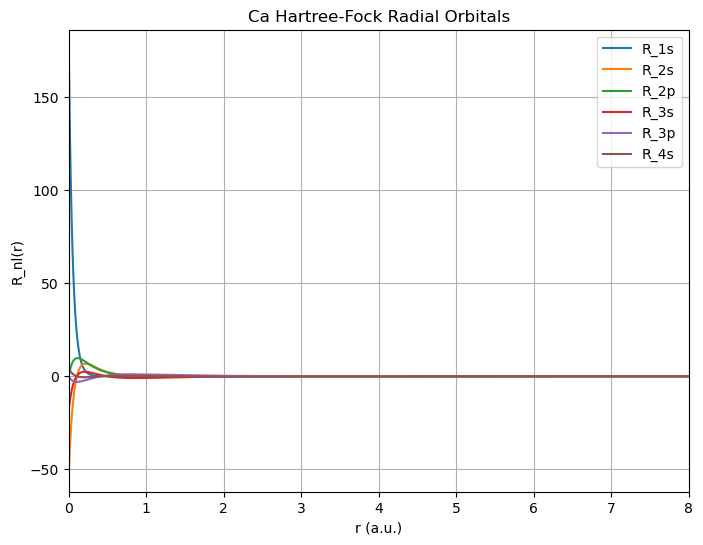

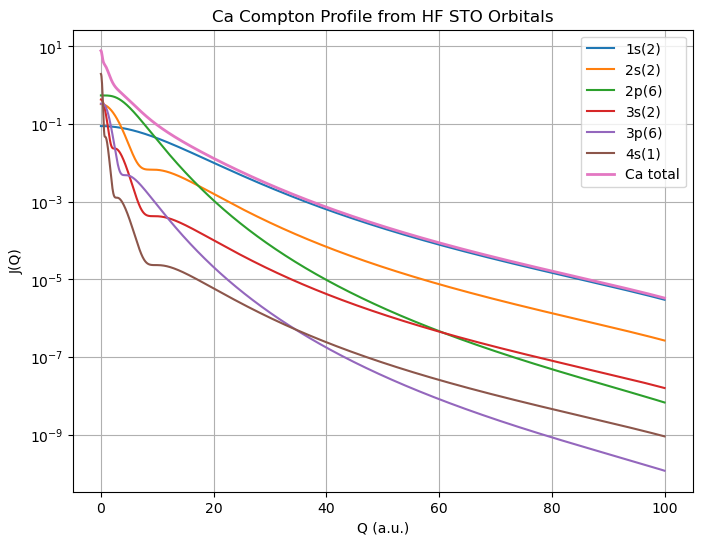

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.special import spherical_jn, factorial
from scipy.integrate import cumulative_trapezoid

# =====================================================
# Calcium Hartree-Fock STO data
# Ca: 1s2 2s2 2p6 3s2 3p6 4s2
# Ground term: 4S
# Format: (n_j, Z_j, C_j)
# =====================================================

calcium_1s = [
    (1, 17.6670,  1.176575),

    (2, 24.5295, -0.119414),
    (2,  7.2525,  0.000730),

    (3, 21.3493, -0.086509),
    (3,  3.6185,  0.000185),
    (3,  2.6126, -0.000097),

    (4,  8.7808,  0.000145),
    (4,  6.0113, -0.000317),
    (4,  1.5770,  0.000021),
    (4,  1.0566, -0.000025),
    (4,  0.7584,  0.000005),
]

calcium_2s = [
    (1, 17.6670, -0.341543),

    (2, 24.5295, -0.019904),
    (2,  7.2525,  1.150570),

    (3, 21.3493, -0.033142),
    (3,  3.6185, -0.000762),
    (3,  2.6126,  0.001467),

    (4,  8.7808, -0.068959),
    (4,  6.0113, -0.016219),
    (4,  1.5770, -0.000184),
    (4,  1.0566,  0.000124),
    (4,  0.7584, -0.000044),
]

calcium_3s = [
    (1, 17.6670, -0.117803),

    (2, 24.5295, -0.010168),
    (2,  7.2525,  0.468206),

    (3, 21.3493, -0.016715),
    (3,  3.6185, -0.640251),
    (3,  2.6126, -0.441778),

    (4,  8.7808,  0.043103),
    (4,  6.0113,  0.064309),
    (4,  1.5770, -0.001947),
    (4,  1.0566, -0.000314),
    (4,  0.7584, -0.000058),
]

calcium_4s = [
    (1, 17.6670,  0.028125),

    (2, 24.5295,  0.002534),
    (2,  7.2525, -0.113880),

    (3, 21.3493,  0.004109),
    (3,  3.6185,  0.179379),
    (3,  2.6126,  0.115506),

    (4,  8.7808, -0.014022),
    (4,  6.0113,  0.020813),
    (4,  1.5770, -0.331747),
    (4,  1.0566, -0.522462),
    (4,  0.7584, -0.257798),
]

calcium_2p = [
    (2, 28.8909,  0.001400),
    (2, 11.9319,  0.348898),
    (2,  6.0967,  0.406540),
    (2,  2.5605,  0.003420),

    (3,  9.4272,  0.300142),
    (3,  2.1782, -0.000861),
    (3,  1.3295,  0.000083),
]

calcium_3p = [
    (2, 28.8909, -0.000342),
    (2, 11.9319, -0.076856),
    (2,  6.0967, -0.433592),
    (2,  2.5605,  0.877080),

    (3,  9.4272, -0.015449),
    (3,  2.1782,  0.312083),
    (3,  1.3295,  0.020164),
]
# =====================================================
# STO normalization constant
# N_j = sqrt((2Z)^(2n+1)/(2n)!)
# =====================================================

def N_sto(n, Z):
    return np.sqrt((2*Z)**(2*n + 1) / factorial(2*n, exact=False))

def R_nl(r, coeffs):
    R = np.zeros_like(r)
    for n, Z, C in coeffs:
        N = N_sto(n, Z)
        R += C * N * r**(n-1) * np.exp(-Z*r)
    return R
# =====================================================
# Grids
# =====================================================

r = np.linspace(1e-6, 60.0, 20000)     # radial grid
p = np.arange(0.0, 120.0 + 0.05, 0.05) # momentum grid
Q = np.arange(0.0, 100.0 + 0.05, 0.05) # Q grid

# =====================================================
# Calculate chi_nl(p)
# chi_nl(p) = sqrt(2/pi) int R_nl(r) j_l(pr) r^2 dr
# =====================================================

def chi_p(p_grid, r_grid, R_grid, l):
    chi = []

    for pp in p_grid:
        jl = spherical_jn(l, pp*r_grid)
        integrand = R_grid * jl * r_grid**2
        val = np.sqrt(2/np.pi) * np.trapz(integrand, r_grid)
        chi.append(val)

    return np.array(chi)

# =====================================================
# Calculate J(Q)
# I(p) = |chi(p)|^2 p^2
# J(Q) = 1/2 int_Q^inf I(p)/p dp
# =====================================================

def calculate_J(p_grid, chi_grid, Q_grid):
    I = chi_grid**2 * p_grid**2

    integrand = np.zeros_like(p_grid)
    integrand[1:] = I[1:] / p_grid[1:]

    # Reverse cumulative integral from p to infinity
    rev_integral = cumulative_trapezoid(
        integrand[::-1],
        p_grid[::-1],
        initial=0
    )

    J_p = -0.5 * rev_integral[::-1]

    # Interpolate J from p-grid to Q-grid
    J_Q = np.interp(Q_grid, p_grid, J_p)

    return I, J_Q

# =====================================================
# Build Calcium radial orbitals
# =====================================================
def print_R_formula(coeffs, name):
    print(f"\n{name}(r) =")

    for n, Z, C in coeffs:
        N = N_sto(n, Z)
        A = C * N

        if n == 1:
            print(f"{A:+.4f} * exp(-{Z:.4f} r)")
        elif n == 2:
            print(f"{A:+.4f} * r * exp(-{Z:.4f} r)")
        elif n == 3:
            print(f"{A:+.4f} * r^2 * exp(-{Z:.4f} r)")
            
R1s = R_nl(r, calcium_1s)
R2s = R_nl(r, calcium_2s)
R3s = R_nl(r, calcium_3s)
R2p = R_nl(r, calcium_2p)
R3p = R_nl(r, calcium_3p)
R4s = R_nl(r, calcium_4s)

print_R_formula(calcium_1s, "K_R1s")
print_R_formula(calcium_2s, "K_R2s")
print_R_formula(calcium_3s, "K_R3s")
print_R_formula(calcium_2p, "K_R2p")
print_R_formula(calcium_3p, "K_R3p")
print_R_formula(calcium_3p, "K_R4s")
# =====================================================
# Momentum-space wavefunctions
# =====================================================

chi_1s = chi_p(p, r, R1s, l=0)
chi_2s = chi_p(p, r, R2s, l=0)
chi_3s = chi_p(p, r, R3s, l=0)
chi_2p = chi_p(p, r, R2p, l=1)
chi_3p = chi_p(p, r, R3p, l=1)
chi_4s = chi_p(p, r, R4s, l=0)

# =====================================================
# Momentum densities and Compton profiles
# =====================================================

I_1s, J_1s = calculate_J(p, chi_1s, Q)
I_2s, J_2s = calculate_J(p, chi_2s, Q)
I_3s, J_3s = calculate_J(p, chi_3s, Q)
I_2p, J_2p = calculate_J(p, chi_2p, Q)
I_3p, J_3p = calculate_J(p, chi_3p, Q)
I_4s, J_4s = calculate_J(p, chi_4s, Q)
# Ca has 1s(2) 2s(2) 2s(2) 2p(6) 3s(2) 3p(6) 4s(2)
J_total = 2*J_1s + 2*J_2s + 6*J_2p + 2*J_3s + 6*J_3p + 2*J_4s

# =====================================================
# Print and save table
# =====================================================
table = pd.DataFrame({
    "Q": Q,
    "J_1s_one_electron": J_1s,
    "J_2s_one_electron": J_2s,
    "J_3s_one_electron": J_3s,
    "J_2p_one_electron": J_2p,
    "J_3p_one_electron": J_3p,
    "J_4s_one_electron": J_4s,
    "J_1s(2)": 2*J_1s,
    "J_2s(2)": 2*J_2s,
    "J_2p(6)": 6*J_2p,
    "J_3s(2)": 2*J_3s,
    "J_3p(6)": 6*J_3p,
    "J_4s(1)": J_4s,
    "J_total_Ca": J_total
    })
print(table)
table.to_csv("Ca_STO_HF_Compton_profile.csv", index=False)

# =====================================================
# Plot radial orbitals
# =====================================================

plt.figure(figsize=(8,6))
plt.plot(r, R1s, label="R_1s")
plt.plot(r, R2s, label="R_2s")
plt.plot(r, R2p, label="R_2p")
plt.plot(r, R3s, label="R_3s")
plt.plot(r, R3p, label="R_3p")
plt.plot(r, R4s, label="R_4s")
plt.xlim(0, 8)
plt.xlabel("r (a.u.)")
plt.ylabel("R_nl(r)")
plt.title("Ca Hartree-Fock Radial Orbitals")
plt.grid(True)
plt.legend()
plt.show()

# =====================================================
# Plot Compton profiles
# =====================================================
plt.figure(figsize=(8,6))
plt.plot(Q, 2*J_1s, label="1s(2)")
plt.plot(Q, 2*J_2s, label="2s(2)")
plt.plot(Q, 6*J_2p, label="2p(6)")
plt.plot(Q, J_3s, label="3s(2)")
plt.plot(Q, J_3p, label="3p(6)")
plt.plot(Q, J_4s, label="4s(1)")
plt.plot(Q, J_total, label="Ca total", linewidth=2)

plt.xlabel("Q (a.u.)")
plt.ylabel("J(Q)")
plt.title("Ca Compton Profile from HF STO Orbitals")
plt.yscale("log")
plt.grid(True)
plt.legend()
plt.show()